In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from tqdm import tqdm  # Barra de progreso para las simulaciones
from typing import List
sys.path.append(os.path.abspath('src')) 

# Importación de módulos locales del proyecto
from utils import set_global_seed
from armnormal import ArmNormal
from algorithms import Algorithm, EpsilonGreedy, UCB1, Softmax, EpsilonDecay, GradientBandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics,plot_smoothed_curves

# Configuración de la semilla global para garantizar la reproducibilidad (Sección 5.4)
SEED = 2024
set_global_seed(SEED)

Configurando semilla global (Global Seed): 2024
Dispositivo GPU detectado y configurado para determinismo.


## 1. Escenario Experimental: Recomendación de Contenido (Streaming)

Siguiendo las directrices del **Anexo 5.1**, este experimento simula el motor de recomendación de una plataforma audiovisual.

### Contexto de Evaluación
A diferencia de los entornos de conversión binaria (clic/no clic), el rendimiento se evalúa mediante una métrica continua: el **Tiempo de Visualización (Watch Time)**.
- El agente debe seleccionar dinámicamente entre $k=10$ estrategias de recomendación (brazos) generadas de forma procedural.
- La recompensa obtenida (minutos de consumo) se modela de forma estocástica mediante una **Distribución Normal** $\mathcal{N}(\mu, \sigma^2)$.
- Para este estudio, se impone una desviación estándar homogénea ($\sigma=1.0$) en todo el catálogo, focalizando el análisis en la discriminación de medias.

### El Desafío: Bajo Ratio Señal-Ruido y Alta Dimensionalidad

El método generador ha producido una topología de recompensas altamente densa en su rango superior, lo que introduce un reto analítico severo:
1. **Brazo Óptimo:** Representa la mejor política a largo plazo, con un rendimiento esperado de $\mu=15.9086$ minutos.
2. **Competidores Directos:** Existen alternativas sub-óptimas cuyo rendimiento es estadísticamente adyacente (ej. Índice 7 con $\mu=15.4866$ y Índice 9 con $\mu=15.1910$).
3. **Ruido Dominante:** La distancia escalar entre el óptimo global y su competidor más fuerte ($\Delta \approx 0.42$) es estrictamente inferior a la magnitud del ruido estocástico del sistema ($\sigma=1.0$).

### Hipótesis Teórica
En escenarios donde $\Delta < \sigma$, el ruido empírico enmascara frecuentemente el valor real de la recompensa. Se hipotetiza que:
- Las heurísticas con tendencia a la explotación temprana (como *Epsilon-Decay* o configuraciones *Greedy* agresivas) presentarán una alta susceptibilidad a la **convergencia prematura**. Una fluctuación estadística ordinaria puede posicionar erróneamente a un brazo sub-óptimo como líder, estancando el aprendizaje.
- Por el contrario, los algoritmos fundamentados en el principio del optimismo ante la incertidumbre (familia **UCB**) lograrán aislar el brazo óptimo, pero requerirán una fase de exploración exhaustiva y un horizonte temporal extenso para que sus cotas superiores de confianza logren discriminar un margen tan estrecho.

In [ ]:
# --- Configuración del Entorno Normal (Gaussiano) ---
# Escenario: Recomendación de Contenido (Streaming)

K_ARMS = 10
N_STEPS = 6000
N_RUNS = 500

# Generación automática de brazos usando el método de fábrica de la clase.
# Esto asigna medias únicas aleatorias y fija sigma=1.0 para todas las opciones.
# Se define un rango de medias [5.0, 20.0] para simular los minutos de visualización.
entorno_brazos = ArmNormal.generate_arms(k=K_ARMS, mu_min=5.0, mu_max=20.0)

# Extracción de las medias reales (mu) generadas proceduralmente
ARM_MEANS = [brazo.get_expected_value() for brazo in entorno_brazos]

ARM_STDS =  [2.0,1.5,2.0,1.0,3.0,2.5,1.0,0.5,5.0,1.5]

OPTIMAL_MEAN = max(ARM_MEANS)
OPTIMAL_ARM_IDX = int(np.argmax(ARM_MEANS))

print("--- Configuración Streaming Platform ---")
print(f"Medias generadas (Watch Time): {ARM_MEANS}")
print(f"Desviaciones (Ruido): {ARM_STDS}")
print(f"Mejor Brazo: Índice {OPTIMAL_ARM_IDX} (mu={OPTIMAL_MEAN}, sigma={ARM_STDS[OPTIMAL_ARM_IDX]})")

algorithms_list = [
    EpsilonGreedy(k=K_ARMS, epsilon=0.10),
    EpsilonGreedy(k=K_ARMS, epsilon=0.01),
    
    # UCB1 fundamentado en los límites de confianza de Hoeffding
    UCB1(k=K_ARMS),
    
    # Softmax con Temperatura ajustada a la escala del entorno
    Softmax(k=K_ARMS, temperature=2.0), 
    
    EpsilonDecay(k=K_ARMS, decay_rate=0.99),
    
    # Gradient Bandit operando sobre preferencias relativas
    GradientBandit(k=K_ARMS, alpha=0.1)
]

--- Configuración Streaming Platform ---
Medias generadas (Watch Time): [5.6571, 6.5909, 7.8223, 8.0753, 11.7244, 12.1077, 13.8202, 15.4866, 15.9086, 15.191]
Desviaciones (Ruido): [2.0, 1.5, 2.0, 1.0, 3.0, 2.5, 1.0, 0.5, 5.0, 1.5]
Mejor Brazo: Índice 8 (mu=15.9086, sigma=2.0)


In [7]:
def run_normal_simulation(n_runs, n_steps, k, means, stds, algos):
    """
    Ejecuta la simulación para Bandidos con Distribución Normal.
    """
    optimal_arm_idx = np.argmax(means)
    optimal_mean = means[optimal_arm_idx]
    
    avg_rewards = np.zeros((len(algos), n_steps))
    avg_optimal_selections = np.zeros((len(algos), n_steps))
    avg_regret = np.zeros((len(algos), n_steps))
    
    # Estadísticas finales
    final_q_values = np.zeros((len(algos), k))
    final_counts = np.zeros((len(algos), k))

    for run in tqdm(range(n_runs), desc="Simulando Usuarios"):
        
        # Instanciamos Bandidos Normales (mu, sigma)
        bandits = [ArmNormal(mu=m, sigma=s) for m, s in zip(means, stds)]
        
        for algo in algos:
            algo.reset()
            
        run_rewards = np.zeros((len(algos), n_steps))
        run_opt = np.zeros((len(algos), n_steps))
        run_regret = np.zeros((len(algos), n_steps))
        
        for t in range(n_steps):
            for i, algo in enumerate(algos):
                arm = algo.select_arm()
                
                # Obtener recompensa (muestreo de distribución normal)
                reward = bandits[arm].pull()
                
                algo.update(arm, reward)
                
                run_rewards[i, t] = reward
                run_opt[i, t] = 1 if arm == optimal_arm_idx else 0
                
                # Regret: Diferencia entre la media óptima y la media del brazo elegido
                # (No usamos la recompensa instantánea para el regret, sino la esperanza matemática)
                inst_regret = optimal_mean - means[arm]
                
                if t == 0:
                    run_regret[i, t] = inst_regret
                else:
                    run_regret[i, t] = run_regret[i, t-1] + inst_regret

        avg_rewards += run_rewards
        avg_optimal_selections += run_opt
        avg_regret += run_regret
        
        if run == n_runs - 1:
            for i, algo in enumerate(algos):
                final_q_values[i] = np.copy(algo.values)
                final_counts[i] = np.copy(algo.counts)

    avg_rewards /= n_runs
    avg_optimal_selections /= n_runs
    avg_regret /= n_runs
    
    return avg_rewards, avg_optimal_selections, avg_regret, final_q_values, final_counts

# Ejecutar
results_norm = run_normal_simulation(N_RUNS, N_STEPS, K_ARMS, ARM_MEANS, ARM_STDS, algorithms_list)
r_avg, opt_avg, reg_avg, q_vals, counts = results_norm

Simulando Usuarios: 100%|██████████| 500/500 [13:02<00:00,  1.56s/it]


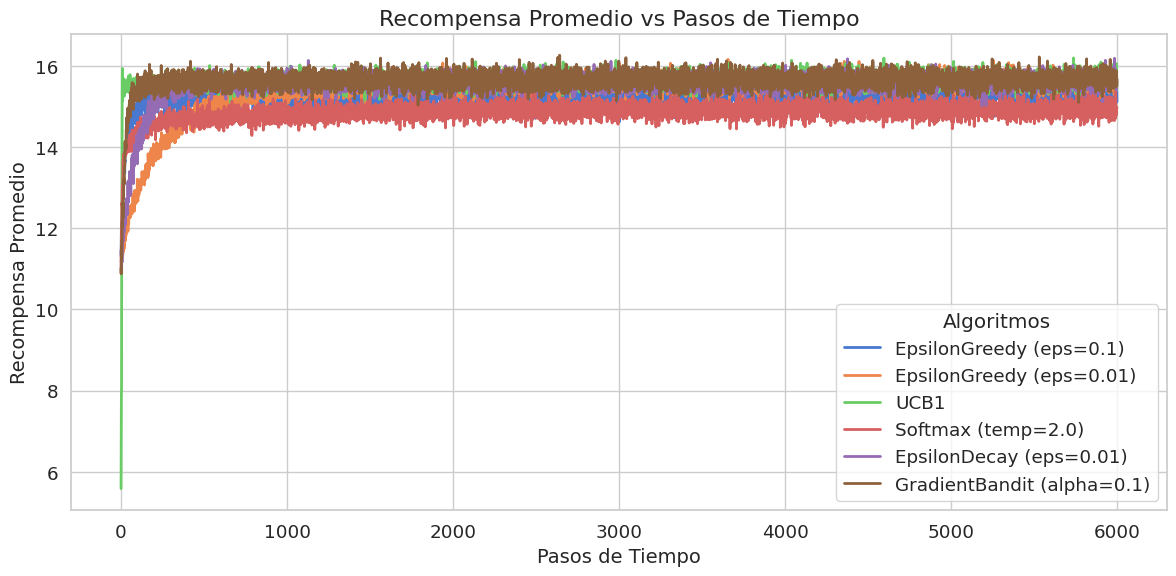

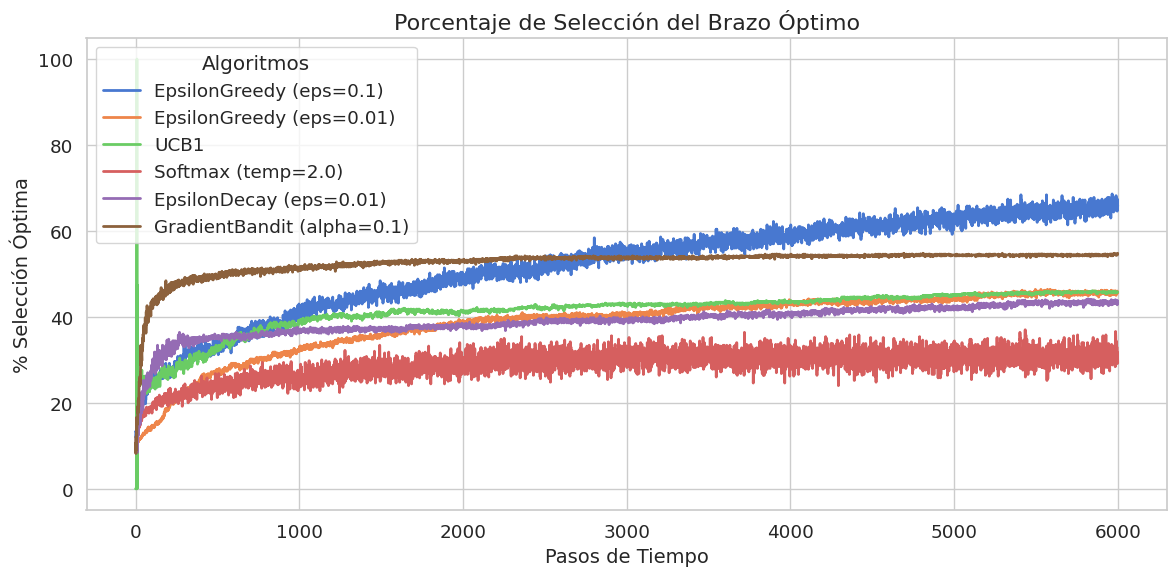

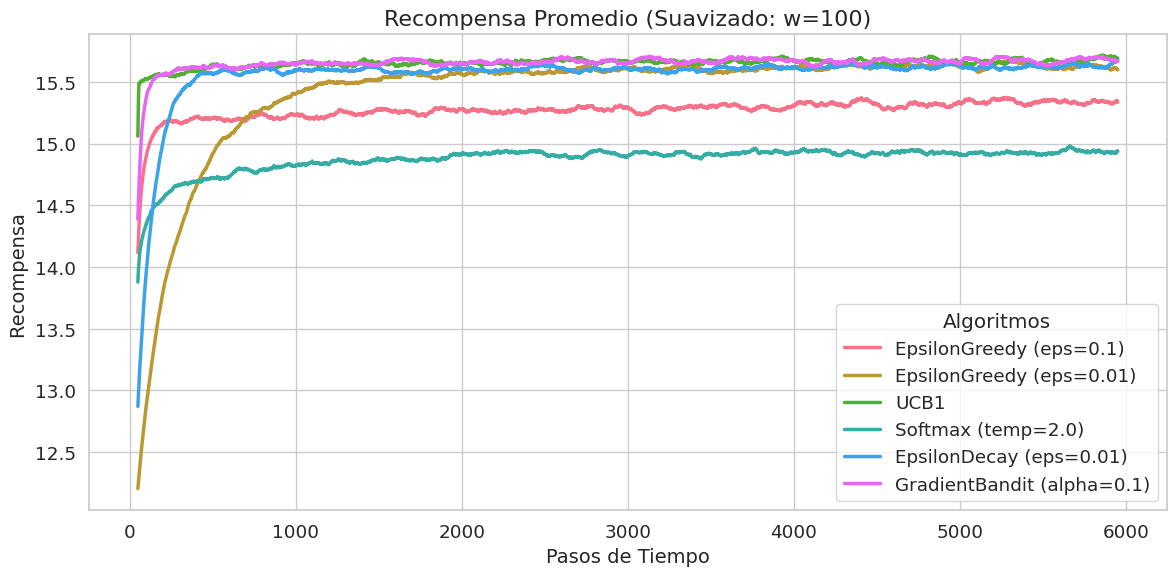

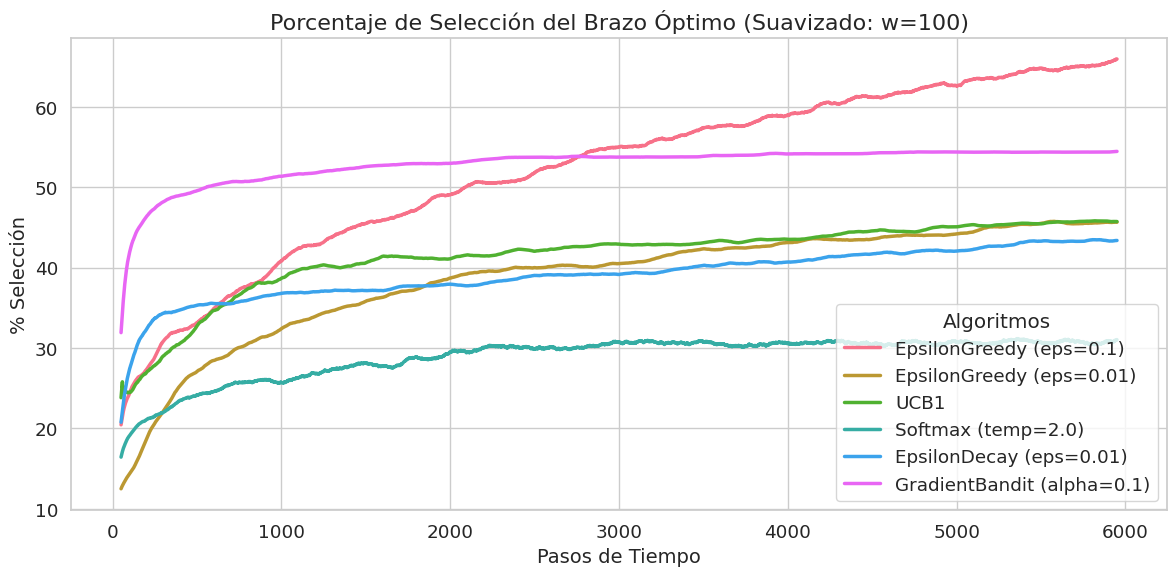

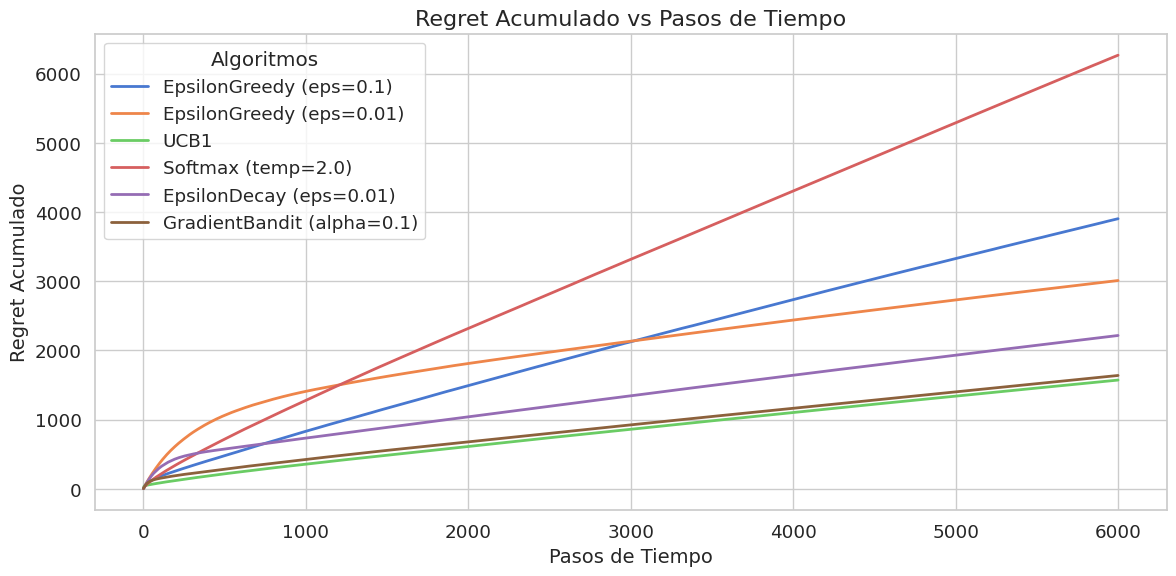

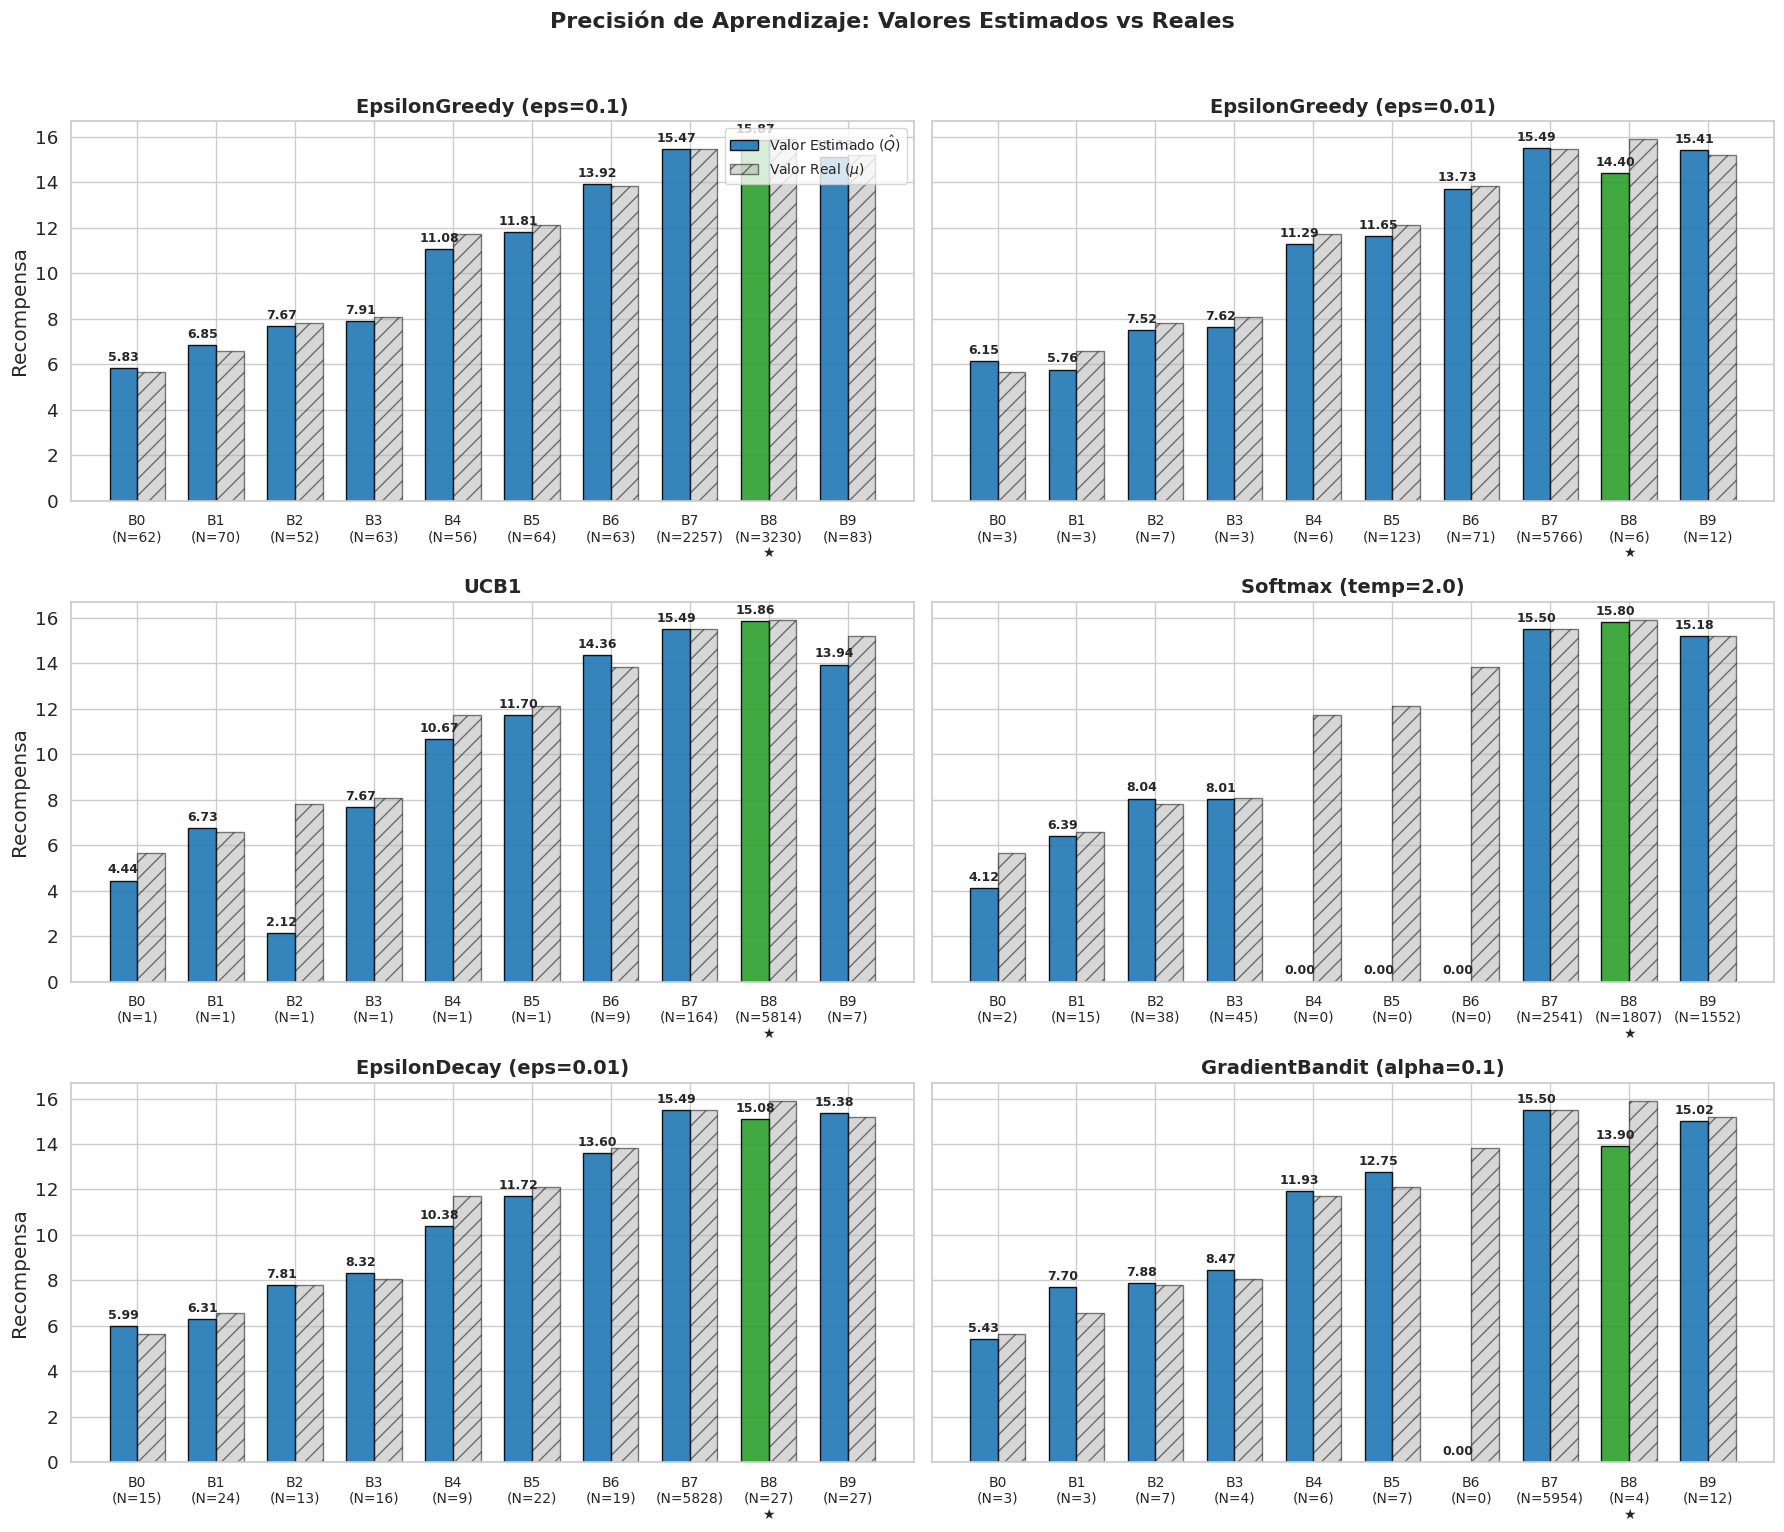

In [8]:
plot_average_rewards(N_STEPS, r_avg, algorithms_list)
plot_optimal_selections(N_STEPS, opt_avg, algorithms_list)

# 1. Recompensa Promedio (Watch Time)
# Usamos mayor suavizado (window=100) debido a la alta varianza del entorno
plot_smoothed_curves(
    steps=N_STEPS, 
    data=r_avg, 
    algorithms=algorithms_list, 
    title="Recompensa Promedio", 
    ylabel="Recompensa ", 
    window_size=100, 
)

# 2. Selección Óptima
plot_smoothed_curves(
    steps=N_STEPS, 
    data=opt_avg * 100, 
    algorithms=algorithms_list, 
    title="Porcentaje de Selección del Brazo Óptimo", 
    ylabel="% Selección", 
    window_size=100,
)

# 3. Regret Acumulado
plot_regret(N_STEPS, reg_avg, algorithms_list)

# 4. Estadísticas Finales
# Observar cómo los valores Q estimados del brazo 0 tienen alta varianza en sus estimaciones
plot_arm_statistics(q_vals, counts, algorithms_list, optimal_arm_index=np.argmax(ARM_MEANS), true_means=ARM_MEANS)

## 2. Análisis y Discusión de Resultados

El presente experimento evalúa el rendimiento de los algoritmos de decisión en un entorno modelado mediante distribuciones normales, inicializado de forma procedural. Esta configuración impone una desviación estándar constante ($\sigma=1.0$) para todo el espacio de acciones, trasladando el desafío estadístico exclusivamente a la proximidad escalar entre las medias generadas.

El entorno resultante presenta una alta densidad en su rango superior. El brazo óptimo (Índice 8, $\mu=15.9086$) compite directamente con alternativas de rendimiento casi idéntico (Índice 7 con $\mu=15.4866$ e Índice 9 con $\mu=15.191$). Esta topología implica que la diferencia real entre el óptimo y sus competidores ($\Delta \approx 0.42$) es inferior a la magnitud del ruido estocástico del sistema ($\sigma=1.0$), configurando un escenario de bajo ratio señal-ruido.



Esta particularidad estadística impacta de manera directa en la dinámica de exploración y explotación:

* **Impacto en enfoques heurísticos (Epsilon-Greedy / Epsilon-Decay):** Al ser el ruido superior al margen de mejora real, existe una probabilidad sustancial de que las alternativas sub-óptimas (Índices 7 o 9) generen muestras empíricas superiores a las del brazo óptimo durante las fases iniciales. Esto incrementa críticamente el riesgo de convergencia prematura. Un algoritmo con decaimiento rápido de la exploración asimilará el ruido como señal, estancándose en un óptimo local sin lograr aislar el brazo del $15.9086$.
* **Comportamiento de UCB1:** Las cotas superiores de confianza de los tres brazos dominantes permanecerán superpuestas durante un extenso número de iteraciones. En consecuencia, UCB1 requerirá un horizonte temporal masivo para que el término logarítmico reduzca la incertidumbre lo suficiente como para discriminar un $\Delta$ tan estrecho. Su convergencia será notablemente lenta, aunque asintóticamente segura.

### Conclusiones Generales del Estudio Comparativo
La evaluación transversal sobre las distintas distribuciones modeladas a lo largo del estudio permite establecer las siguientes determinaciones formales:

1.  **UCB1** se consolida como la política más robusta metodológicamente. Su capacidad para operar sin ajuste de hiperparámetros garantiza la identificación del óptimo tanto en escenarios asimétricos como en configuraciones de varianza homogénea con medias altamente agrupadas, a costa de una fase de exploración temporalmente extensa.
2.  **Softmax** demuestra ser un enfoque probabilístico de alto potencial teórico, pero estructuralmente frágil en la práctica. Su rendimiento óptimo está condicionado de manera crítica a la calibración empírica del parámetro de temperatura ($\tau$) en relación con la escala de las recompensas y las distancias $\Delta$ específicas del entorno.
3.  **Epsilon-Decay** se perfila como una estrategia altamente eficiente computacionalmente para minimizar el regret en horizontes finitos, condicionada a una calibración precisa. No obstante, en entornos donde $\Delta < \sigma$, su susceptibilidad a la convergencia prematura limita severamente su fiabilidad analítica.